# Предсказание риска задержки доставки в цепочке поставок

**Задача:** бинарная классификация — по характеристикам заказа предсказать, будет ли доставка задержана.

**Датасет:** DataCo Smart Supply Chain (~180k строк, 50+ признаков)

**Источник:** https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

In [3]:
df = pd.read_csv('../data/raw/DataCoSupplyChainDataset.csv', encoding='latin-1')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок')
df.head()

Размер датасета: 180519 строк, 53 колонок


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## 1. Первичный осмотр данных

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Колонки с пропусками:')
print(missing)
print(f'\nВсего колонок с пропусками: {len(missing)}')

Колонки с пропусками:
Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64

Всего колонок с пропусками: 4


In [6]:
df.describe().round(2)

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,Longitude,Order Customer Id,Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180516.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,24840.00,180519.00,180519.00,0.0,180519.00,180519.0
mean,3.50,2.93,21.97,183.11,0.55,31.85,6691.38,35921.13,5.44,29.72,-84.92,6691.38,36221.89,692.51,20.66,0.10,90260.00,141.23,0.12,2.13,203.77,183.11,21.97,55426.13,692.51,31.85,NaN,141.23,0.0
std,1.62,1.37,104.43,120.04,0.50,15.64,4162.92,37542.46,1.63,9.81,21.43,4162.92,21045.38,336.45,21.80,0.07,52111.49,139.73,0.47,1.45,132.27,120.04,104.43,31919.28,336.45,15.64,NaN,139.73,0.0
min,0.00,0.00,-4274.98,7.49,0.00,2.00,1.00,603.00,2.00,-33.94,-158.03,1.00,1.00,19.00,0.00,0.00,1.00,9.99,-2.75,1.00,9.99,7.49,-4274.98,1040.00,19.00,2.00,NaN,9.99,0.0
25%,2.00,2.00,7.00,104.38,0.00,18.00,3258.50,725.00,4.00,18.27,-98.45,3258.50,18057.00,403.00,5.40,0.04,45130.50,50.00,0.08,1.00,119.98,104.38,7.00,23464.00,403.00,18.00,NaN,50.00,0.0
50%,3.00,4.00,31.52,163.99,1.00,29.00,6457.00,19380.00,5.00,33.14,-76.85,6457.00,36140.00,627.00,14.00,0.10,90260.00,59.99,0.27,1.00,199.92,163.99,31.52,59405.00,627.00,29.00,NaN,59.99,0.0
75%,5.00,4.00,64.80,247.40,1.00,45.00,9779.00,78207.00,7.00,39.28,-66.37,9779.00,54144.00,1004.00,29.99,0.16,135389.50,199.99,0.36,3.00,299.95,247.40,64.80,90008.00,1004.00,45.00,NaN,199.99,0.0
max,6.00,4.00,911.80,1939.99,1.00,76.00,20757.00,99205.00,12.00,48.78,115.26,20757.00,77204.00,1363.00,500.00,0.25,180519.00,1999.99,0.50,5.00,1999.99,1939.99,911.80,99301.00,1363.00,76.00,NaN,1999.99,0.0


In [7]:
print('Распределение таргета (Late_delivery_risk):')
print(df['Late_delivery_risk'].value_counts())
print(f'\nДоля задержек: {df["Late_delivery_risk"].mean():.2%}')

Распределение таргета (Late_delivery_risk):
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Доля задержек: 54.83%


## 2. Очистка данных

Удаляем:
- Колонки с утечкой данных (data leak): `Delivery Status`, `Days for shipping (real)`
- Персональные данные: `Customer Email`, `Customer Password`, `Customer Fname`, `Customer Lname`, `Customer Street`
- Бесполезные колонки: `Product Image`, `Product Description`, `Order Zipcode`, `Customer Zipcode`
- ID-колонки: `Order Id`, `Order Item Id`, `Customer Id`, `Order Customer Id`, `Product Card Id`, `Order Item Cardprod Id`

In [8]:
leak_cols = ['Delivery Status', 'Days for shipping (real)']

personal_cols = [
    'Customer Email', 'Customer Password',
    'Customer Fname', 'Customer Lname', 'Customer Street'
]

useless_cols = [
    'Product Image', 'Product Description',
    'Order Zipcode', 'Customer Zipcode', 'Product Status'
]

id_cols = [
    'Order Id', 'Order Item Id', 'Customer Id',
    'Order Customer Id', 'Product Card Id',
    'Order Item Cardprod Id', 'Category Id',
    'Department Id', 'Product Category Id'
]

drop_cols = leak_cols + personal_cols + useless_cols + id_cols
df_clean = df.drop(columns=drop_cols)

print(f'Было: {df.shape[1]} колонок')
print(f'Удалено: {len(drop_cols)} колонок')
print(f'Осталось: {df_clean.shape[1]} колонок')
print(f'\nОставшиеся колонки:')
print(df_clean.columns.tolist())

Было: 53 колонок
Удалено: 21 колонок
Осталось: 32 колонок

Оставшиеся колонки:
['Type', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'shipping date (DateOrders)', 'Shipping Mode']


In [9]:
print('Типы данных:')
print(df_clean.dtypes.value_counts())
print(f'\nПропуски: {df_clean.isnull().sum().sum()}')
print(f'Дубликаты: {df_clean.duplicated().sum()}')

Типы данных:
str        17
float64    12
int64       3
Name: count, dtype: int64

Пропуски: 0
Дубликаты: 0


In [10]:
df_clean = df_clean.drop_duplicates()
print(f'Размер после удаления дубликатов: {df_clean.shape}')

Размер после удаления дубликатов: (180519, 32)


## 3. Разделение признаков на категориальные и числовые

In [11]:
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
num_cols = df_clean.select_dtypes(include='number').columns.tolist()

# Таргет отдельно
num_cols.remove('Late_delivery_risk')

print(f'Категориальные ({len(cat_cols)}): {cat_cols}')
print(f'\nЧисловые ({len(num_cols)}): {num_cols}')

Категориальные (17): ['Type', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'shipping date (DateOrders)', 'Shipping Mode']

Числовые (14): ['Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price']


C:\Users\Cоня\AppData\Local\Temp\ipykernel_18816\3830438698.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include='object').columns.tolist()


## 4. Визуализации

### 4.1 Распределение таргета

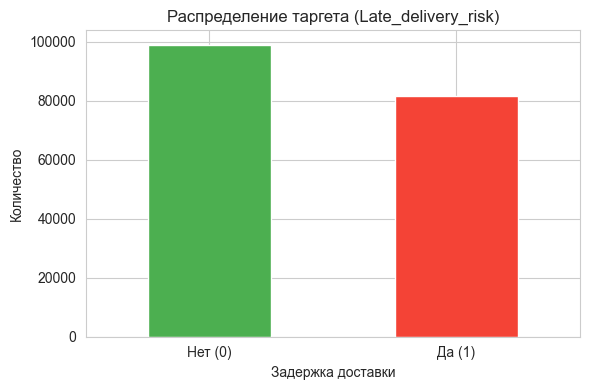

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
df_clean['Late_delivery_risk'].value_counts().plot(kind='bar', ax=ax, color=['#4CAF50', '#F44336'])
ax.set_title('Распределение таргета (Late_delivery_risk)')
ax.set_xlabel('Задержка доставки')
ax.set_ylabel('Количество')
ax.set_xticklabels(['Нет (0)', 'Да (1)'], rotation=0)
plt.tight_layout()
plt.show()

### 4.2 Распределение числовых признаков

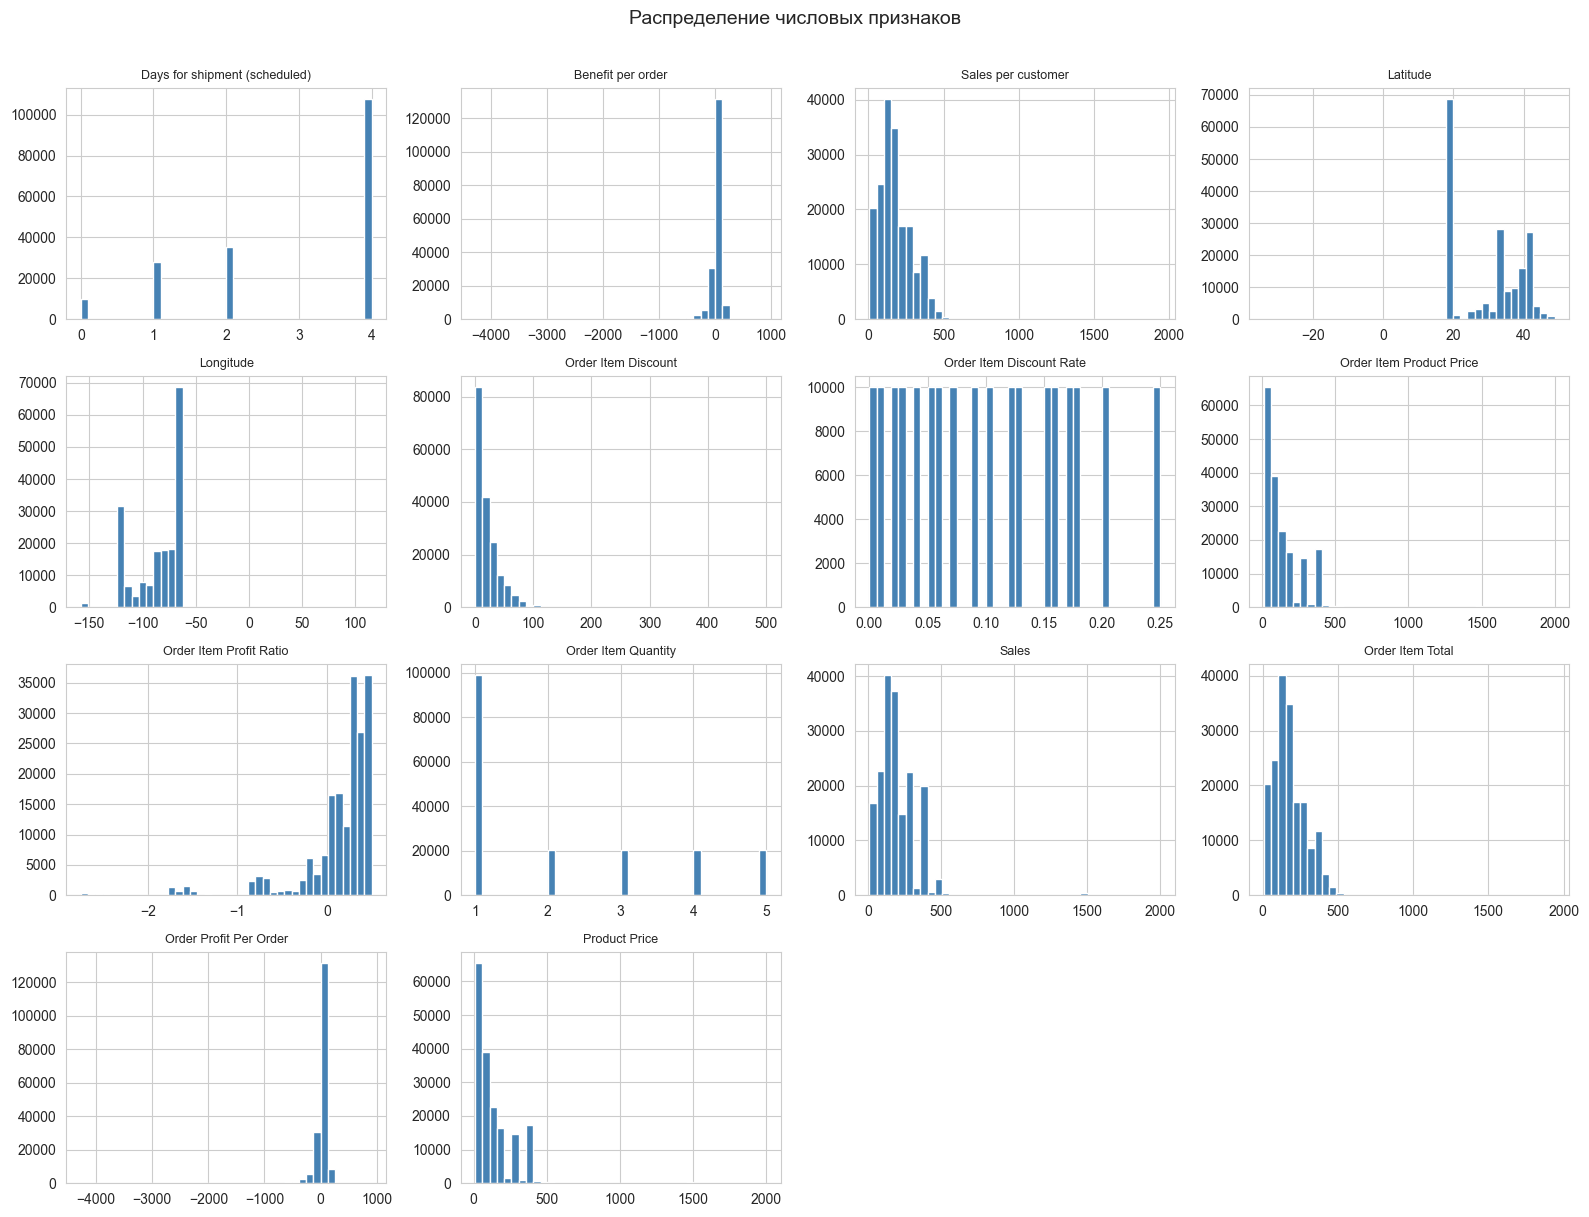

In [13]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)

# Скрыть пустые ячейки
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Распределение числовых признаков', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Связь категориальных признаков с таргетом

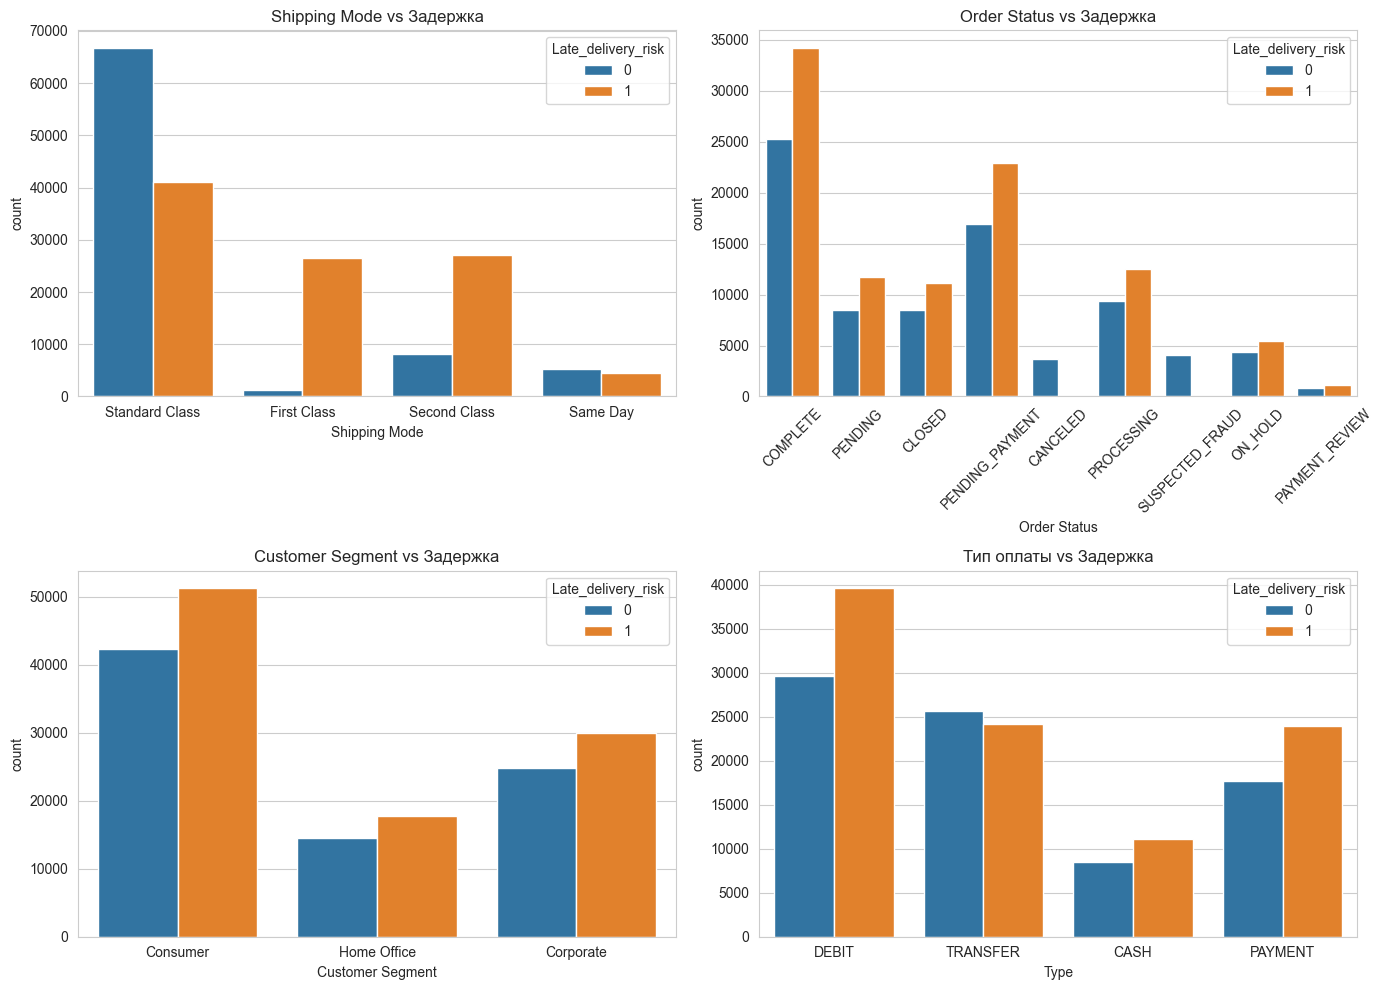

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Shipping Mode vs таргет
sns.countplot(data=df_clean, x='Shipping Mode', hue='Late_delivery_risk', ax=axes[0, 0])
axes[0, 0].set_title('Shipping Mode vs Задержка')

# Order Status vs таргет
sns.countplot(data=df_clean, x='Order Status', hue='Late_delivery_risk', ax=axes[0, 1])
axes[0, 1].set_title('Order Status vs Задержка')
axes[0, 1].tick_params(axis='x', rotation=45)

# Customer Segment vs таргет
sns.countplot(data=df_clean, x='Customer Segment', hue='Late_delivery_risk', ax=axes[1, 0])
axes[1, 0].set_title('Customer Segment vs Задержка')

# Type (тип оплаты) vs таргет
sns.countplot(data=df_clean, x='Type', hue='Late_delivery_risk', ax=axes[1, 1])
axes[1, 1].set_title('Тип оплаты vs Задержка')

plt.tight_layout()
plt.show()

### 4.4 Корреляция числовых признаков с таргетом

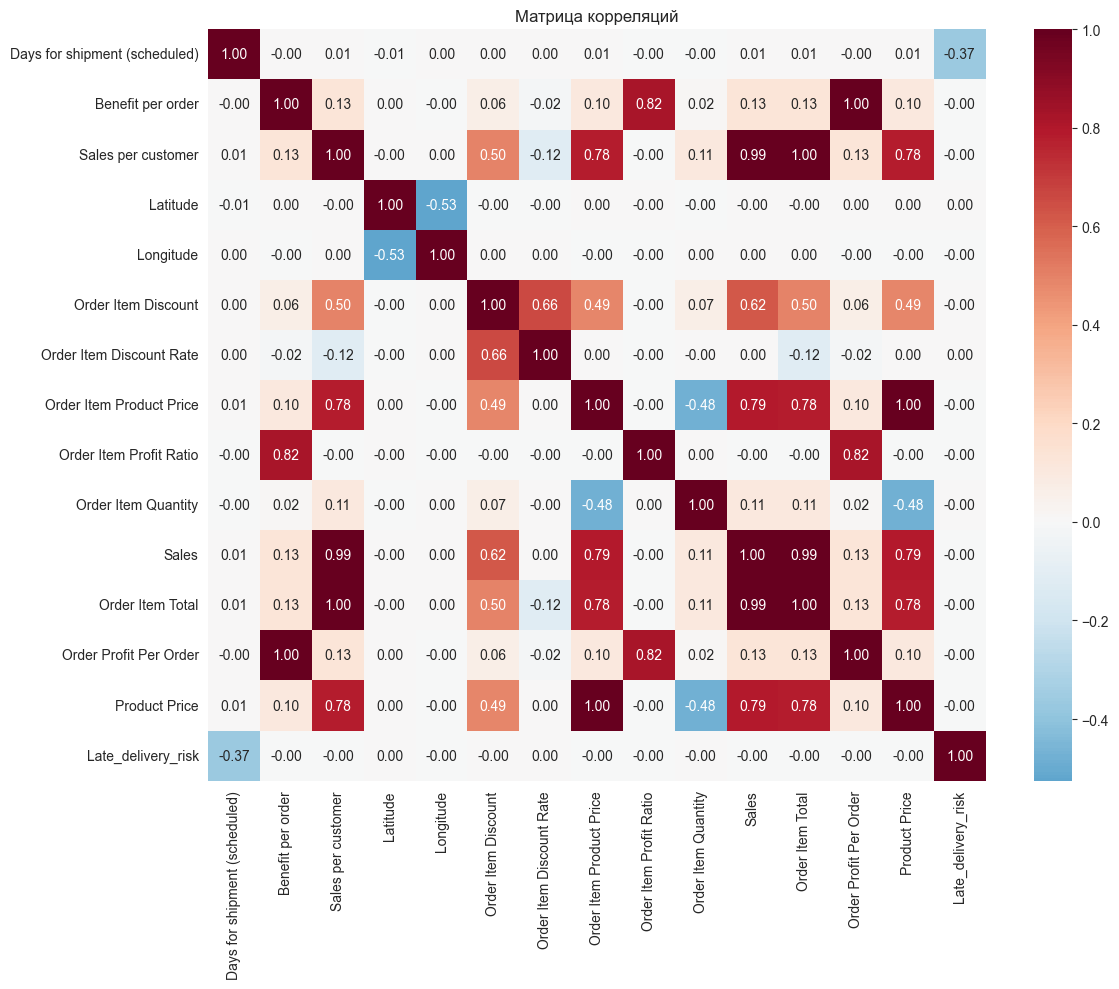

In [15]:
corr = df_clean[num_cols + ['Late_delivery_risk']].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Матрица корреляций')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

### 5.1 Удаление мультиколлинеарных признаков

Обнаружены пары с корреляцией ≥ 0.99:
- `Product Price` ≈ `Order Item Product Price` (1.0) → убираем `Product Price`
- `Order Profit Per Order` ≈ `Benefit per order` (1.0) → убираем `Benefit per order`
- `Order Item Total` ≈ `Sales per customer` (1.0) → убираем `Order Item Total`

Пара `Sales` и `Sales per customer` (0.99) — оставляем обе, так как визуально распределения отличаются, а планируемые модели (деревья) устойчивы к мультиколлинеарности.

In [16]:
multicollinear_cols = [
    'Product Price',
    'Benefit per order',
    'Order Item Total'
]
df_clean = df_clean.drop(columns=multicollinear_cols)
print(f'Удалено {len(multicollinear_cols)} мультиколлинеарных колонок')
print(f'Осталось: {df_clean.shape[1]} колонок')

Удалено 3 мультиколлинеарных колонок
Осталось: 29 колонок


### 5.2 Создание новых признаков из дат

In [17]:
df_clean['order_date'] = pd.to_datetime(df_clean['order date (DateOrders)'])

df_clean['order_month'] = df_clean['order_date'].dt.month
df_clean['order_dayofweek'] = df_clean['order_date'].dt.dayofweek
df_clean['order_hour'] = df_clean['order_date'].dt.hour

df_clean = df_clean.drop(columns=[
    'order date (DateOrders)', 'shipping date (DateOrders)',
    'order_date'
])

print('Новые признаки из дат:')
print(df_clean[['order_month', 'order_dayofweek', 'order_hour']].head())

Новые признаки из дат:
   order_month  order_dayofweek  order_hour
0            1                2          22
1            1                5          12
2            1                5          12
3            1                5          11
4            1                5          11


### 5.3 Удаление высококардинальных категориальных признаков

Признаки с сотнями уникальных значений (города, штаты, названия продуктов) создадут слишком много фичей при кодировании. Оставляем только информативные категории с небольшим числом уникальных значений.

In [18]:
cat_cols_updated = df_clean.select_dtypes(include=['object', 'str']).columns.tolist()

for col in cat_cols_updated:
    print(f'{col}: {df_clean[col].nunique()} уникальных')

Type: 4 уникальных
Category Name: 50 уникальных
Customer City: 563 уникальных
Customer Country: 2 уникальных
Customer Segment: 3 уникальных
Customer State: 46 уникальных
Department Name: 11 уникальных
Market: 5 уникальных
Order City: 3597 уникальных
Order Country: 164 уникальных
Order Region: 23 уникальных
Order State: 1089 уникальных
Order Status: 9 уникальных
Product Name: 118 уникальных
Shipping Mode: 4 уникальных


In [19]:
high_card_cols = [
    'Customer City',
    'Customer State',
    'Order City',
    'Order Country',
    'Order State',
    'Product Name',
    'Customer Country', 
]
df_clean = df_clean.drop(columns=high_card_cols)

cat_cols_final = df_clean.select_dtypes(include=['object', 'str']).columns.tolist()
print(f'Осталось категориальных: {len(cat_cols_final)}')
for col in cat_cols_final:
    print(f'  {col}: {df_clean[col].nunique()} уникальных → {df_clean[col].unique()}')

Осталось категориальных: 8
  Type: 4 уникальных → <StringArray>
['DEBIT', 'TRANSFER', 'CASH', 'PAYMENT']
Length: 4, dtype: str
  Category Name: 50 уникальных → <StringArray>
[      'Sporting Goods',               'Cleats',        'Shop By Sport',
      'Women's Apparel',          'Electronics',         'Boxing & MMA',
     'Cardio Equipment',             'Trade-In',     'Kids' Golf Clubs',
   'Hunting & Shooting',  'Baseball & Softball',       'Men's Footwear',
     'Camping & Hiking', 'Consumer Electronics',             'Cameras ',
            'Computers',           'Basketball',               'Soccer',
       'Girls' Apparel',          'Accessories',     'Women's Clothing',
               'Crafts',       'Men's Clothing',     'Tennis & Racquet',
  'Fitness Accessories',      'As Seen on  TV!',           'Golf Balls',
    'Strength Training',  'Children's Clothing',             'Lacrosse',
                'Baby ',              'Fishing',               'Books ',
                 'DVDs'

### 5.4 Кодирование категориальных признаков

Оставшиеся категориальные признаки имеют небольшое количество уникальных значений. Используем One-Hot Encoding.

In [20]:
df_model = pd.get_dummies(df_clean, drop_first=True)

print(f'Итоговый размер датасета: {df_model.shape}')
print(f'Колонки: {df_model.columns.tolist()[:10]}...')  # первые 10

Итоговый размер датасета: (180519, 116)
Колонки: ['Days for shipment (scheduled)', 'Sales per customer', 'Late_delivery_risk', 'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity']...


## 6. Разбиение на выборки

Используем стратифицированный сплит 70/15/15 (train/val/test) для сохранения пропорций таргета. Фиксируем `random_state` для воспроизводимости.

In [21]:
X = df_model.drop(columns='Late_delivery_risk')
y = df_model['Late_delivery_risk']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=SEED, stratify=y_temp
)

print(f'Train: {X_train.shape[0]} ({y_train.mean():.2%} положительных)')
print(f'Val:   {X_val.shape[0]} ({y_val.mean():.2%} положительных)')
print(f'Test:  {X_test.shape[0]} ({y_test.mean():.2%} положительных)')

Train: 126435 (54.83% положительных)
Val:   27006 (54.83% положительных)
Test:  27078 (54.83% положительных)


## 7. Выбор метрики качества

Задача — бинарная классификация со сбалансированными классами (55/45).

**Основная метрика: F1-score** — гармоническое среднее precision и recall. Выбрана, потому что:
- Классы почти сбалансированы, но нам важно одинаково хорошо находить как задержки, так и вовремя доставленные заказы
- В бизнес-контексте и пропуск задержки (FN), и ложная тревога (FP) имеют стоимость

**Дополнительно:** Accuracy, ROC-AUC для общей картины.

In [22]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, classification_report

def evaluate_model(model, X_tr, y_tr, X_v, y_v, name='Model'):
    """Обучает модель и выводит метрики на train и val."""
    model.fit(X_tr, y_tr)
    
    y_pred_train = model.predict(X_tr)
    y_pred_val = model.predict(X_v)
    
    print(f'=== {name} ===')
    print(f'{"Метрика":<15} {"Train":>8} {"Val":>8}')
    print(f'{"Accuracy":<15} {accuracy_score(y_tr, y_pred_train):>8.4f} {accuracy_score(y_v, y_pred_val):>8.4f}')
    print(f'{"F1-score":<15} {f1_score(y_tr, y_pred_train):>8.4f} {f1_score(y_v, y_pred_val):>8.4f}')
    print(f'{"ROC-AUC":<15} {roc_auc_score(y_tr, y_pred_train):>8.4f} {roc_auc_score(y_v, y_pred_val):>8.4f}')
    print(f'\nClassification Report (Val):')
    print(classification_report(y_v, y_pred_val))
    
    return model

## 8. Baseline-модель

Начинаем с простой логистической регрессии — классический baseline.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

baseline = LogisticRegression(random_state=SEED, max_iter=1000)
baseline = evaluate_model(baseline, X_train_scaled, y_train, X_val_scaled, y_val, 'Logistic Regression (Baseline)')

=== Logistic Regression (Baseline) ===
Метрика            Train      Val
Accuracy          0.7249   0.7206
F1-score          0.6939   0.6875
ROC-AUC           0.7416   0.7377

Classification Report (Val):
              precision    recall  f1-score   support

           0       0.63      0.91      0.75     12199
           1       0.89      0.56      0.69     14807

    accuracy                           0.72     27006
   macro avg       0.76      0.74      0.72     27006
weighted avg       0.77      0.72      0.71     27006



## 9. Эксперименты с моделями

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=SEED, max_depth=10)
dt = evaluate_model(dt, X_train, y_train, X_val, y_val, 'Decision Tree')

=== Decision Tree ===
Метрика            Train      Val
Accuracy          0.7420   0.7327
F1-score          0.7226   0.7111
ROC-AUC           0.7558   0.7468

Classification Report (Val):
              precision    recall  f1-score   support

           0       0.65      0.89      0.75     12199
           1       0.87      0.60      0.71     14807

    accuracy                           0.73     27006
   macro avg       0.76      0.75      0.73     27006
weighted avg       0.77      0.73      0.73     27006



In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf = evaluate_model(rf, X_train, y_train, X_val, y_val, 'Random Forest')

=== Random Forest ===
Метрика            Train      Val
Accuracy          1.0000   0.7569
F1-score          1.0000   0.7503
ROC-AUC           1.0000   0.7666

Classification Report (Val):
              precision    recall  f1-score   support

           0       0.68      0.87      0.76     12199
           1       0.86      0.67      0.75     14807

    accuracy                           0.76     27006
   macro avg       0.77      0.77      0.76     27006
weighted avg       0.78      0.76      0.76     27006



In [26]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

results = []

models = {
    'Logistic Regression': (baseline, X_val_scaled),
    'Decision Tree': (dt, X_val),
    'Random Forest': (rf, X_val),
}

for name, (model, X_v) in models.items():
    y_pred = model.predict(X_v)
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_val, y_pred), 4),
        'F1-score': round(f1_score(y_val, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_val, y_pred), 4),
    })

results_df = pd.DataFrame(results).sort_values('F1-score', ascending=False)
print('Сравнение моделей:')
print(results_df.to_string(index=False))

Сравнение моделей:
              Model  Accuracy  F1-score  ROC-AUC
      Random Forest    0.7569    0.7503   0.7666
      Decision Tree    0.7327    0.7111   0.7468
Logistic Regression    0.7206    0.6875   0.7377


## 10. Важность признаков (Random Forest)

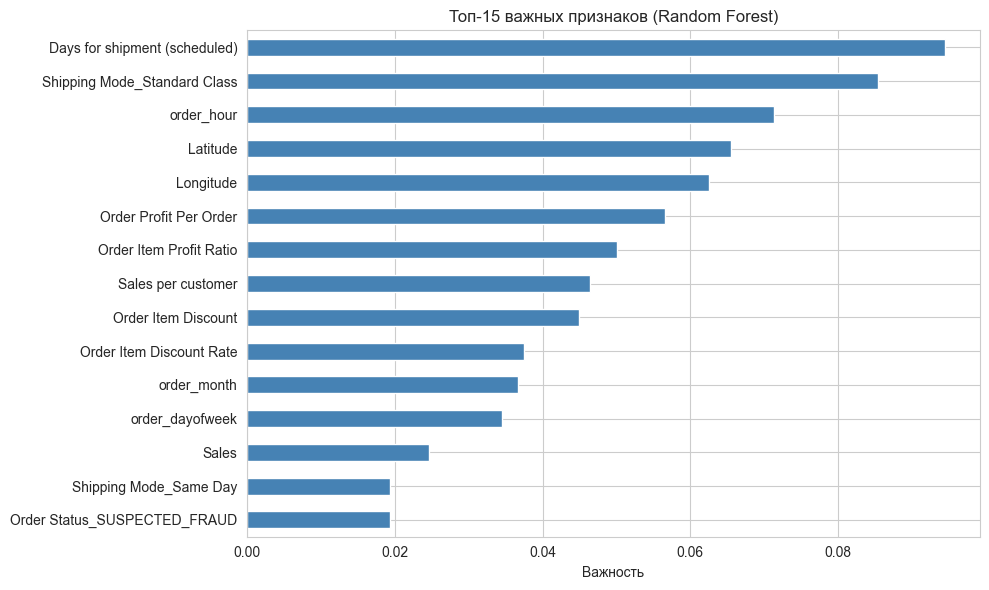

In [27]:
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Топ-15 важных признаков (Random Forest)')
ax.set_xlabel('Важность')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Выводы по CP1

**Данные:**
- Датасет содержит 180 519 заказов и 53 исходных признака
- После очистки (удаление утечек, персональных данных, дубликатов признаков) осталось 116 фичей (после One-Hot Encoding)
- Таргет сбалансирован: 55% задержек / 45% без задержки
- Обнаружена и устранена утечка данных через `shipping date`

**Модели (F1-score на валидации):**

| Модель | Accuracy | F1-score | ROC-AUC |
|--------|----------|----------|---------|
| Logistic Regression (baseline) | 0.7206 | 0.6875 | 0.7377 |
| Decision Tree | 0.7327 | 0.7111 | 0.7468 |
| Random Forest | 0.7569 | 0.7503 | 0.7666 |

**Следующие шаги (CP2):**
- Добавить XGBoost, LightGBM
- Подбор гиперпараметров (GridSearch / Optuna)
- Ансамбли и стекинг

---
# CP2: Моделирование и эксперименты

## 12. Дополнительная обработка данных
### 12.1 Обработка выбросов

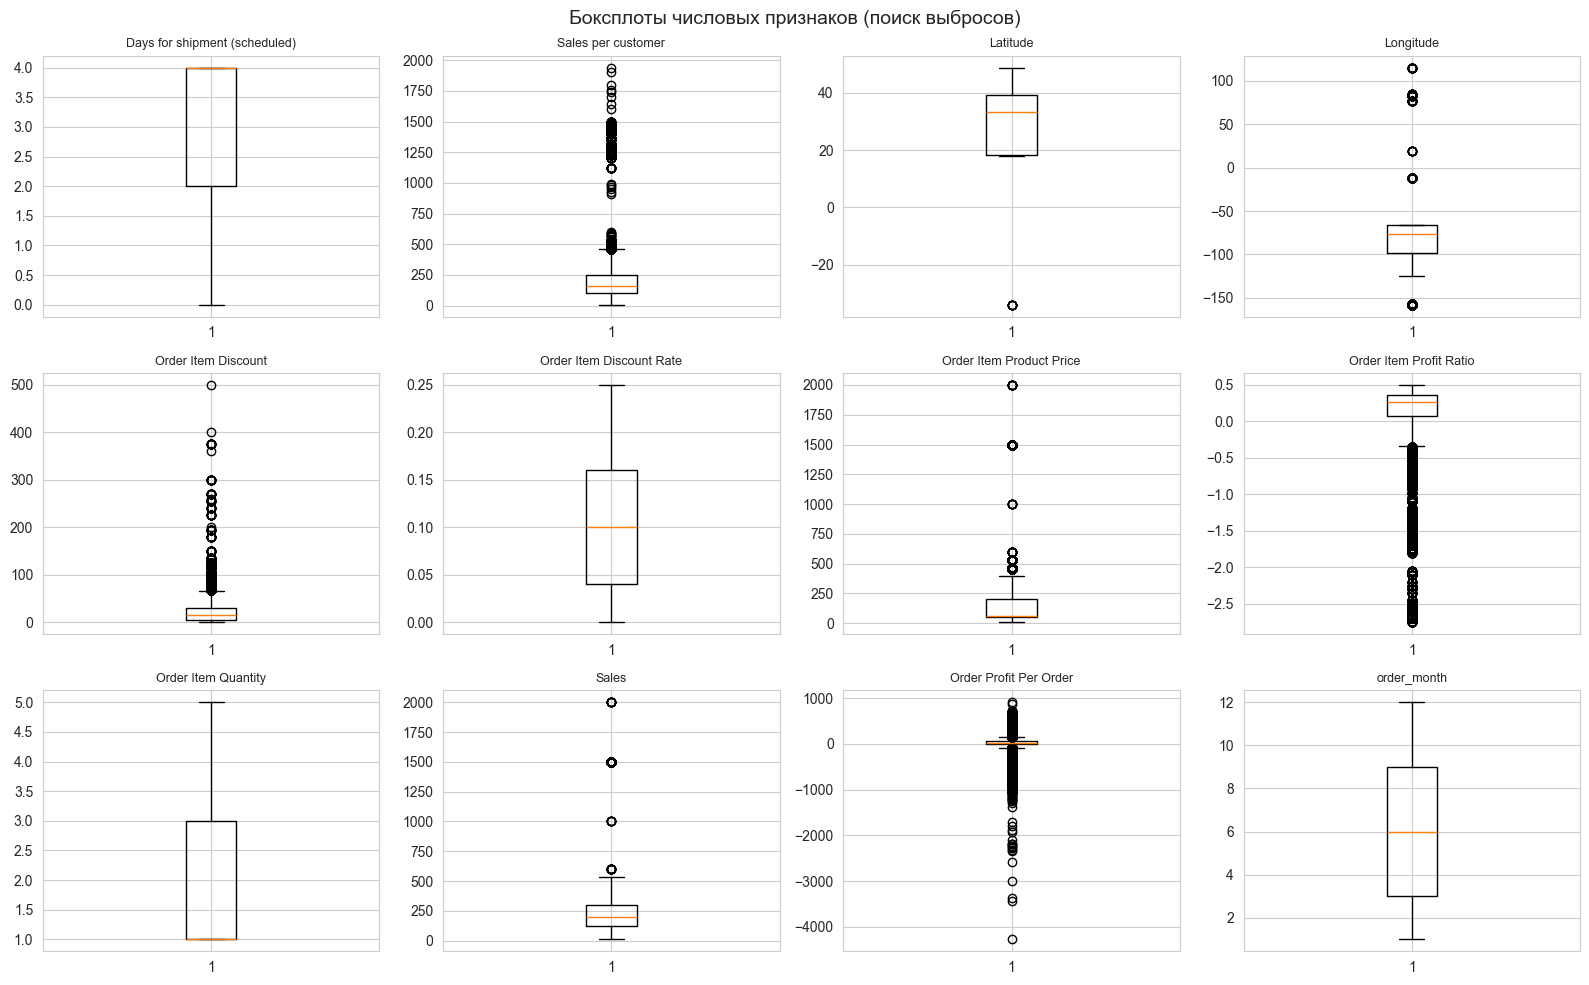

In [28]:
num_features = X_train.select_dtypes(include='number').columns.tolist()

real_num = [c for c in num_features if X_train[c].nunique() > 2]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(real_num):
    if i < len(axes):
        axes[i].boxplot(X_train[col], vert=True)
        axes[i].set_title(col, fontsize=9)

for j in range(len(real_num), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Боксплоты числовых признаков (поиск выбросов)', fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
for col in real_num:
    low = X_train[col].quantile(0.01)
    high = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(low, high)
    X_val[col] = X_val[col].clip(low, high)
    X_test[col] = X_test[col].clip(low, high)

print(f'Выбросы обрезаны по 1-99 перцентилям для {len(real_num)} признаков')

Выбросы обрезаны по 1-99 перцентилям для 14 признаков


## 13. Уменьшение размерности

### 13.1 PCA — визуализация данных в 2D

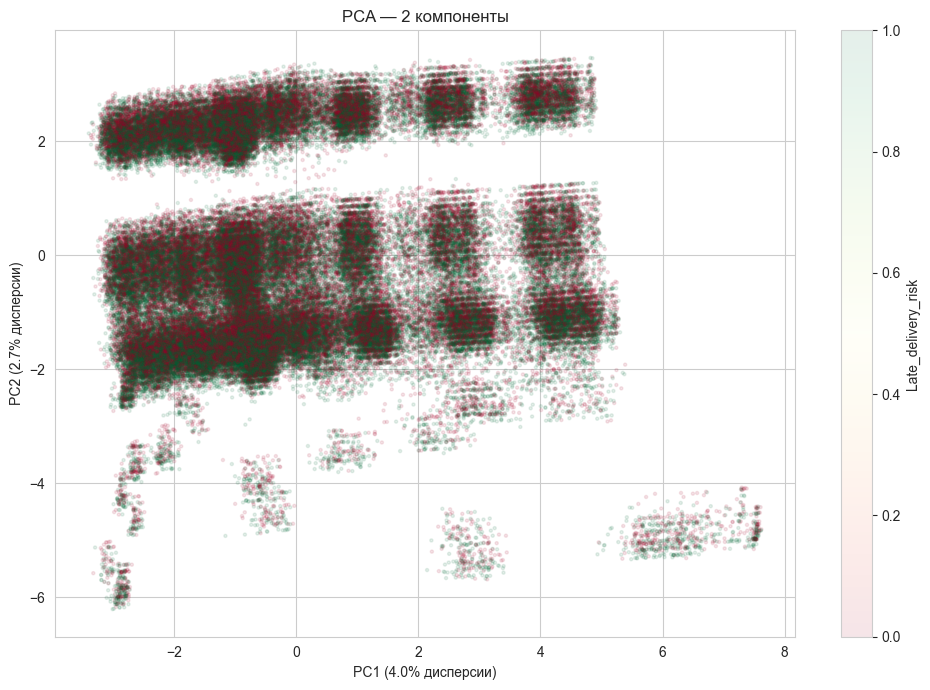

Объяснённая дисперсия 2 компонентами: 6.6%


In [30]:
from sklearn.decomposition import PCA

scaler_pca = StandardScaler()
X_train_pca = scaler_pca.fit_transform(X_train)

pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_train_pca)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, cmap='RdYlGn', alpha=0.1, s=5)
ax.set_title('PCA — 2 компоненты')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} дисперсии)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} дисперсии)')
plt.colorbar(scatter, label='Late_delivery_risk')
plt.tight_layout()
plt.show()

print(f'Объяснённая дисперсия 2 компонентами: {pca.explained_variance_ratio_.sum():.1%}')

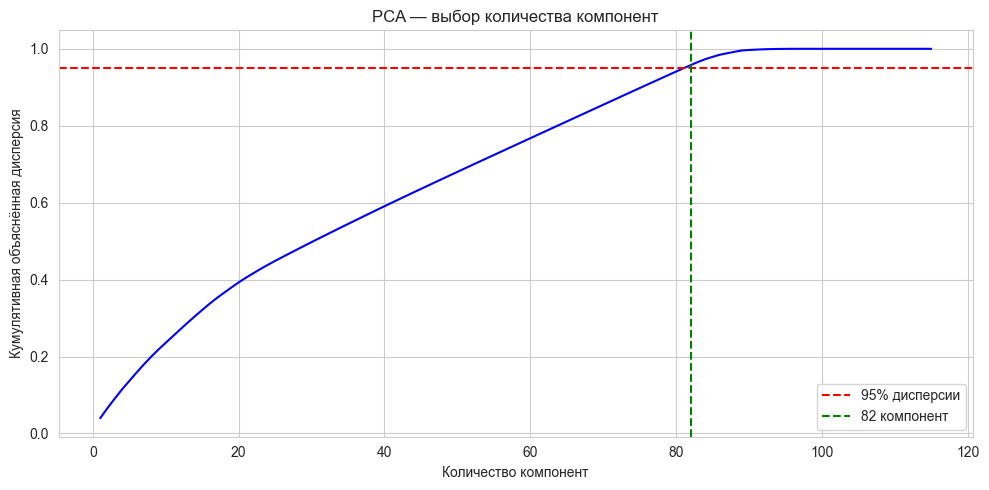

Для 95% дисперсии нужно 82 компонент из 115


In [31]:
pca_full = PCA(random_state=SEED)
pca_full.fit(X_train_pca)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumulative_var >= 0.95) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumulative_var) + 1), cumulative_var, 'b-')
ax.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
ax.axvline(x=n_95, color='g', linestyle='--', label=f'{n_95} компонент')
ax.set_xlabel('Количество компонент')
ax.set_ylabel('Кумулятивная объяснённая дисперсия')
ax.set_title('PCA — выбор количества компонент')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Для 95% дисперсии нужно {n_95} компонент из {X_train.shape[1]}')

### 13.2 Вывод по PCA

PCA-визуализация показывает, что 2 компоненты объясняют лишь 6.6% дисперсии, а для 95% нужно 82 из 115 признаков. Данные высокоразмерны, и PCA не даёт значительного сжатия. Далее работаем с полным набором признаков.

## 14. Эксперименты с моделями

Обучаем 4–5 моделей разных семейств и сравниваем.

In [32]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=11, n_jobs=-1)
knn = evaluate_model(knn, X_train_scaled, y_train, X_val_scaled, y_val, 'KNN (k=11)')

=== KNN (k=11) ===
Метрика            Train      Val
Accuracy          0.7416   0.6640
F1-score          0.7594   0.6853
ROC-AUC           0.7414   0.6636

Classification Report (Val):
              precision    recall  f1-score   support

           0       0.62      0.66      0.64     12199
           1       0.70      0.67      0.69     14807

    accuracy                           0.66     27006
   macro avg       0.66      0.66      0.66     27006
weighted avg       0.67      0.66      0.66     27006



In [33]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=SEED)
gb = evaluate_model(gb, X_train, y_train, X_val, y_val, 'Gradient Boosting')

=== Gradient Boosting ===
Метрика            Train      Val
Accuracy          0.7540   0.7392
F1-score          0.7354   0.7173
ROC-AUC           0.7680   0.7538

Classification Report (Val):
              precision    recall  f1-score   support

           0       0.65      0.90      0.76     12199
           1       0.88      0.60      0.72     14807

    accuracy                           0.74     27006
   macro avg       0.77      0.75      0.74     27006
weighted avg       0.78      0.74      0.74     27006



In [34]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=SEED, n_jobs=-1, eval_metric='logloss'
)
xgb = evaluate_model(xgb, X_train, y_train, X_val, y_val, 'XGBoost')

=== XGBoost ===
Метрика            Train      Val
Accuracy          0.7585   0.7395
F1-score          0.7422   0.7192
ROC-AUC           0.7718   0.7536

Classification Report (Val):
              precision    recall  f1-score   support

           0       0.65      0.90      0.76     12199
           1       0.88      0.61      0.72     14807

    accuracy                           0.74     27006
   macro avg       0.77      0.75      0.74     27006
weighted avg       0.78      0.74      0.74     27006



In [35]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgbm = evaluate_model(lgbm, X_train, y_train, X_val, y_val, 'LightGBM')

=== LightGBM ===
Метрика            Train      Val
Accuracy          0.7530   0.7366
F1-score          0.7342   0.7136
ROC-AUC           0.7670   0.7513

Classification Report (Val):
              precision    recall  f1-score   support

           0       0.65      0.90      0.76     12199
           1       0.88      0.60      0.71     14807

    accuracy                           0.74     27006
   macro avg       0.77      0.75      0.73     27006
weighted avg       0.78      0.74      0.73     27006



In [36]:
results = []

all_models = {
    'Logistic Regression': (baseline, X_val_scaled),
    'KNN (k=11)': (knn, X_val_scaled),
    'Decision Tree': (dt, X_val),
    'Random Forest': (rf, X_val),
    'Gradient Boosting': (gb, X_val),
    'XGBoost': (xgb, X_val),
    'LightGBM': (lgbm, X_val),
}

for name, (model, X_v) in all_models.items():
    y_pred = model.predict(X_v)
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_val, y_pred), 4),
        'F1-score': round(f1_score(y_val, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_val, y_pred), 4),
    })

results_df = pd.DataFrame(results).sort_values('F1-score', ascending=False)
print('Сравнение всех моделей:')
print(results_df.to_string(index=False))

Сравнение всех моделей:
              Model  Accuracy  F1-score  ROC-AUC
      Random Forest    0.7563    0.7494   0.7661
            XGBoost    0.7395    0.7192   0.7536
  Gradient Boosting    0.7392    0.7173   0.7538
           LightGBM    0.7366    0.7136   0.7513
      Decision Tree    0.7315    0.7093   0.7458
Logistic Regression    0.7206    0.6875   0.7377
         KNN (k=11)    0.6640    0.6853   0.6636


## 15. Подбор гиперпараметров (Optuna)

Тюним две лучшие модели: Random Forest и XGBoost.

In [38]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': SEED,
        'n_jobs': -1,
        'eval_metric': 'logloss',
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred)

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=30)

print(f'XGBoost лучший F1: {study_xgb.best_value:.4f}')
print(f'Лучшие параметры: {study_xgb.best_params}')

XGBoost лучший F1: 0.8260
Лучшие параметры: {'n_estimators': 242, 'max_depth': 10, 'learning_rate': 0.29687714561783773, 'subsample': 0.9918585998724915, 'colsample_bytree': 0.9054989579659412, 'min_child_weight': 2}


In [39]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': SEED,
        'n_jobs': -1,
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred)

study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_rf.optimize(objective_rf, n_trials=30)

print(f'Random Forest лучший F1: {study_rf.best_value:.4f}')
print(f'Лучшие параметры: {study_rf.best_params}')

Random Forest лучший F1: 0.7166
Лучшие параметры: {'n_estimators': 366, 'max_depth': 30, 'min_samples_split': 18, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


In [40]:
xgb_tuned = XGBClassifier(**study_xgb.best_params, random_state=SEED, n_jobs=-1, eval_metric='logloss')
xgb_tuned = evaluate_model(xgb_tuned, X_train, y_train, X_val, y_val, 'XGBoost (tuned)')

rf_tuned = RandomForestClassifier(**study_rf.best_params, random_state=SEED, n_jobs=-1)
rf_tuned = evaluate_model(rf_tuned, X_train, y_train, X_val, y_val, 'Random Forest (tuned)')

=== XGBoost (tuned) ===
Метрика            Train      Val
Accuracy          0.9918   0.8152
F1-score          0.9925   0.8260
ROC-AUC           0.9923   0.8168

Classification Report (Val):
              precision    recall  f1-score   support

           0       0.77      0.83      0.80     12199
           1       0.85      0.80      0.83     14807

    accuracy                           0.82     27006
   macro avg       0.81      0.82      0.81     27006
weighted avg       0.82      0.82      0.82     27006

=== Random Forest (tuned) ===
Метрика            Train      Val
Accuracy          0.8784   0.7394
F1-score          0.8838   0.7166
ROC-AUC           0.8821   0.7542

Classification Report (Val):
              precision    recall  f1-score   support

           0       0.65      0.91      0.76     12199
           1       0.89      0.60      0.72     14807

    accuracy                           0.74     27006
   macro avg       0.77      0.75      0.74     27006
weighted avg   

## 16. Ансамбли

In [41]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('xgb', XGBClassifier(**study_xgb.best_params, random_state=SEED, n_jobs=-1, eval_metric='logloss')),
        ('rf', RandomForestClassifier(**study_rf.best_params, random_state=SEED, n_jobs=-1)),
        ('lgbm', LGBMClassifier(n_estimators=200, max_depth=6, random_state=SEED, n_jobs=-1, verbose=-1)),
    ],
    voting='soft'
)
voting = evaluate_model(voting, X_train, y_train, X_val, y_val, 'Voting (XGB + RF + LGBM)')

=== Voting (XGB + RF + LGBM) ===
Метрика            Train      Val
Accuracy          0.9488   0.7836
F1-score          0.9530   0.7813
ROC-AUC           0.9489   0.7920

Classification Report (Val):
              precision    recall  f1-score   support

           0       0.71      0.88      0.79     12199
           1       0.88      0.71      0.78     14807

    accuracy                           0.78     27006
   macro avg       0.79      0.79      0.78     27006
weighted avg       0.80      0.78      0.78     27006



In [42]:
from sklearn.ensemble import StackingClassifier

stacking = StackingClassifier(
    estimators=[
        ('xgb', XGBClassifier(**study_xgb.best_params, random_state=SEED, n_jobs=-1, eval_metric='logloss')),
        ('rf', RandomForestClassifier(**study_rf.best_params, random_state=SEED, n_jobs=-1)),
        ('lgbm', LGBMClassifier(n_estimators=200, max_depth=6, random_state=SEED, n_jobs=-1, verbose=-1)),
    ],
    final_estimator=LogisticRegression(random_state=SEED, max_iter=1000),
    cv=3, n_jobs=-1
)
stacking = evaluate_model(stacking, X_train, y_train, X_val, y_val, 'Stacking (XGB + RF + LGBM)')

=== Stacking (XGB + RF + LGBM) ===
Метрика            Train      Val
Accuracy          0.9820   0.8043
F1-score          0.9836   0.8130
ROC-AUC           0.9820   0.8074

Classification Report (Val):
              precision    recall  f1-score   support

           0       0.75      0.84      0.79     12199
           1       0.85      0.78      0.81     14807

    accuracy                           0.80     27006
   macro avg       0.80      0.81      0.80     27006
weighted avg       0.81      0.80      0.80     27006



In [43]:
all_models_final = {
    'Logistic Regression': (baseline, X_val_scaled),
    'KNN (k=11)': (knn, X_val_scaled),
    'Decision Tree': (dt, X_val),
    'Random Forest': (rf, X_val),
    'Gradient Boosting': (gb, X_val),
    'XGBoost': (xgb, X_val),
    'LightGBM': (lgbm, X_val),
    'RF (tuned)': (rf_tuned, X_val),
    'XGBoost (tuned)': (xgb_tuned, X_val),
    'Voting': (voting, X_val),
    'Stacking': (stacking, X_val),
}

results_final = []
for name, (model, X_v) in all_models_final.items():
    y_pred = model.predict(X_v)
    results_final.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_val, y_pred), 4),
        'F1-score': round(f1_score(y_val, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_val, y_pred), 4),
    })

results_final_df = pd.DataFrame(results_final).sort_values('F1-score', ascending=False)
print('Итоговое сравнение всех моделей:')
print(results_final_df.to_string(index=False))

Итоговое сравнение всех моделей:
              Model  Accuracy  F1-score  ROC-AUC
    XGBoost (tuned)    0.8152    0.8260   0.8168
           Stacking    0.8043    0.8130   0.8074
             Voting    0.7836    0.7813   0.7920
      Random Forest    0.7563    0.7494   0.7661
            XGBoost    0.7395    0.7192   0.7536
  Gradient Boosting    0.7392    0.7173   0.7538
         RF (tuned)    0.7394    0.7166   0.7542
           LightGBM    0.7366    0.7136   0.7513
      Decision Tree    0.7315    0.7093   0.7458
Logistic Regression    0.7206    0.6875   0.7377
         KNN (k=11)    0.6640    0.6853   0.6636


## 17. Финальная модель и оценка на тесте

**Выбор:** XGBoost (tuned) — лучший F1-score (0.826) на валидации. Стекинг показал 0.813, но он значительно сложнее и дольше в обучении, а прирост отрицательный. По принципу Оккама выбираем XGBoost.

In [44]:
y_test_pred = xgb_tuned.predict(X_test)

print('=== Финальная оценка на TEST ===')
print(f'Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}')
print(f'F1-score:  {f1_score(y_test, y_test_pred):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_test_pred):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_test_pred))

=== Финальная оценка на TEST ===
Accuracy:  0.8170
F1-score:  0.8289
ROC-AUC:   0.8180

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.83      0.80     12231
           1       0.85      0.81      0.83     14847

    accuracy                           0.82     27078
   macro avg       0.82      0.82      0.82     27078
weighted avg       0.82      0.82      0.82     27078



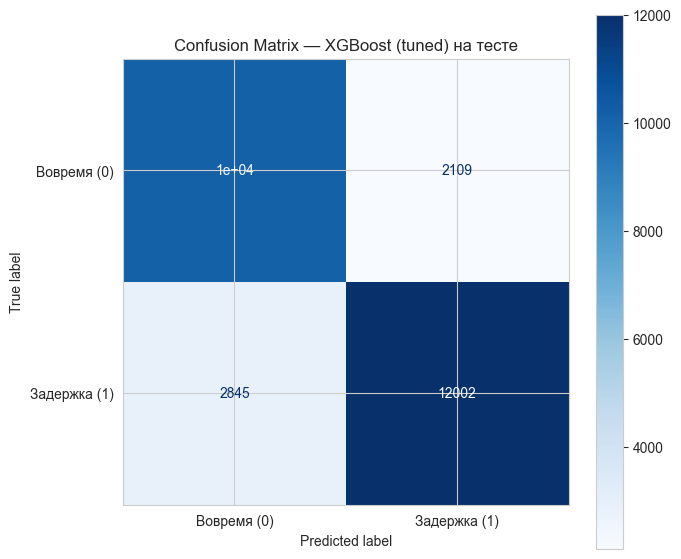

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Вовремя (0)', 'Задержка (1)'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — XGBoost (tuned) на тесте')
plt.tight_layout()
plt.show()

In [46]:
import joblib

joblib.dump(xgb_tuned, '../models/xgb_tuned.pkl')
print('Модель сохранена: models/xgb_tuned.pkl')

Модель сохранена: models/xgb_tuned.pkl


## 18. Выводы по CP2

**Эксперименты:**
- Обучено 7 моделей разных семейств + 2 ансамбля
- Подбор гиперпараметров через Optuna (30 trials) дал рост XGBoost с 0.72 → 0.83 F1
- PCA показал, что данные высокоразмерны (82 компоненты для 95% дисперсии) — сжатие нецелесообразно

**Итоговая таблица:**

| Модель | Accuracy | F1-score | ROC-AUC |
|--------|----------|----------|---------|
| Logistic Regression (baseline) | 0.7206 | 0.6875 | 0.7377 |
| KNN (k=11) | 0.6640 | 0.6853 | 0.6636 |
| Decision Tree | 0.7315 | 0.7093 | 0.7458 |
| Random Forest | 0.7563 | 0.7494 | 0.7661 |
| Gradient Boosting | 0.7392 | 0.7173 | 0.7538 |
| XGBoost | 0.7395 | 0.7192 | 0.7536 |
| LightGBM | 0.7366 | 0.7136 | 0.7513 |
| RF (tuned) | 0.7394 | 0.7166 | 0.7542 |
| **XGBoost (tuned)** | **0.8152** | **0.8260** | **0.8168** |
| Voting | 0.7836 | 0.7813 | 0.7920 |
| Stacking | 0.8043 | 0.8130 | 0.8074 |

**Финальная модель:** XGBoost (tuned) — лучшее соотношение качества и сложности.